# Master of Telegram Ads: VIEWS forecasting - EDA

This notebook is **project-facing**: it documents data quality, distributions, leakage risks, and what features/models are likely to work.
 
 
#### **Task:** predict `VIEWS` using only: `CPM`, `CHANNEL_NAME`, `DATE`.

> Note: `AllData.csv` includes extra columns (`AD_ID`, `CLICKS`, `ACTIONS`) — useful for analysis, but **not allowed** as inference features.

### 1. Import libraries and create Data Frame

In [104]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [105]:
# Load data
path = "data/AllData.csv"
df = pd.read_csv(path)
df.head() # viewing first 5 rows

,AD_ID,CPM,VIEWS,CLICKS,ACTIONS,CHANNEL_NAME,DATE
0,3652,1.2,52,0,0,tanya_in_france,2024-10-02
1,3653,1.2,54,2,0,relocator_cc,2024-10-02
2,3654,1.2,15,1,0,teleportazia,2024-10-02
3,3655,1.5,85,2,1,spetsialist_visa_support,2024-10-02
4,3656,19.4,688,21,3,pitkvch_news,2024-10-02


### 2. Overview

In [107]:
df.shape # Information about shape of Data Frame 

(142609, 7)

In [108]:
df.dtypes # CHANNEL_NAME, DATE are object types;
# All others are float or int

AD_ID             int64
CPM             float64
VIEWS             int64
CLICKS            int64
ACTIONS           int64
CHANNEL_NAME     object
DATE             object
dtype: object

In [109]:
df.isna().sum() # Data for training does not have empty cells

AD_ID           0
CPM             0
VIEWS           0
CLICKS          0
ACTIONS         0
CHANNEL_NAME    0
DATE            0
dtype: int64

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142609 entries, 0 to 142608
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   AD_ID         142609 non-null  int64  
 1   CPM           142609 non-null  float64
 2   VIEWS         142609 non-null  int64  
 3   CLICKS        142609 non-null  int64  
 4   ACTIONS       142609 non-null  int64  
 5   CHANNEL_NAME  142609 non-null  object 
 6   DATE          142609 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 7.6+ MB


### 3) `DATE` preprocessing and coverage

In [111]:
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
df.dtypes # Converting from object to data types

AD_ID                    int64
CPM                    float64
VIEWS                    int64
CLICKS                   int64
ACTIONS                  int64
CHANNEL_NAME            object
DATE            datetime64[ns]
dtype: object

In [112]:
date_min, date_max = df["DATE"].min(), df["DATE"].max()
n_days = df["DATE"].nunique()

# Date range: 2024-10-02 -> 2025-12-17 (430 days)
date_min, date_max, n_days

(Timestamp('2024-10-02 00:00:00'), Timestamp('2025-12-17 00:00:00'), 430)

### 4. Descriptive statistics and tails

In [113]:
num_cols = ["CPM", "VIEWS", "CLICKS", "ACTIONS"] # int or float columns
df[num_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99])# Description of columns with numbers

,CPM,VIEWS,CLICKS,ACTIONS
count,142609.000000,1.426090e+05,142609.000000,142609.000000
mean,8.994971,9.998400e+02,13.245714,4.478245
std,29.404112,7.260922e+03,211.894919,159.825803
min,1.000000,0.000000e+00,0.000000,0.000000
50%,3.530000,2.550000e+02,1.000000,0.000000
90%,19.900000,1.642000e+03,16.000000,3.000000
95%,29.700000,3.196600e+03,35.000000,8.000000
99%,63.000000,1.199692e+04,183.000000,49.000000
max,999.910000,1.136470e+06,48513.000000,37978.000000


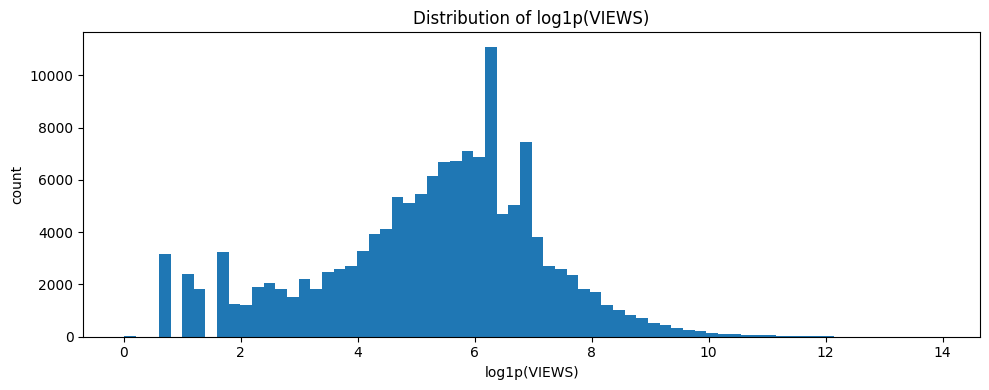

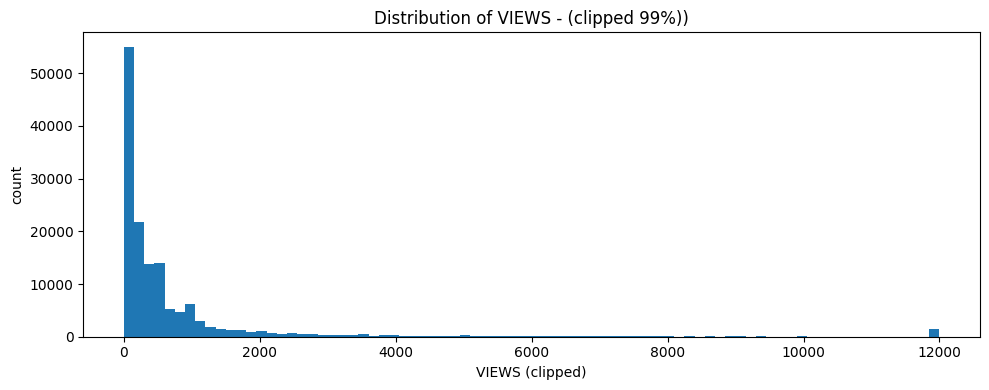

In [129]:
# Histogram where instead of VIEWS.values we use a function of these values log1p(VIEWS.values)
plt.figure(figsize=(10,4))
plt.hist(np.log1p(df["VIEWS"].values), bins=70)
plt.title("Distribution of log1p(VIEWS)")
plt.xlabel("log1p(VIEWS)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# To better display the graph -> trim the extreme part 
p99 = np.quantile(df["VIEWS"].values, 0.99)
views_values_99 = np.clip(df["VIEWS"].values, 0, p99)

plt.figure(figsize=(10,4))
plt.hist(views_values_99, bins=80)
plt.title("Distribution of VIEWS - (clipped 99%))")
plt.xlabel("VIEWS (clipped)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

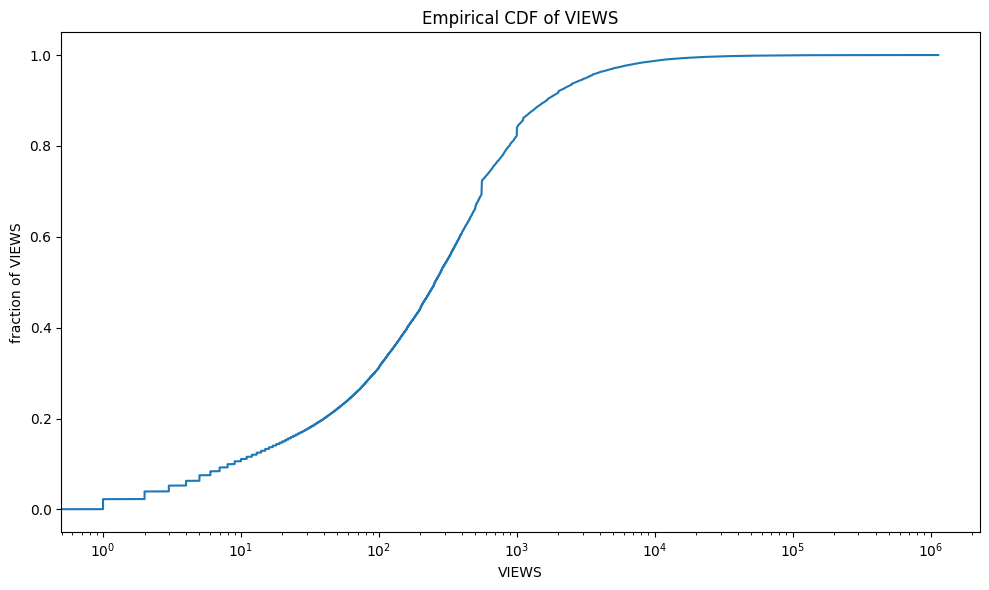

In [131]:
views_values = np.sort(df["VIEWS"].values)
fraction = np.arange(1, len(views_values)+1) / len(views_values) # for Empirical CDF

plt.figure(figsize=(10,6))
plt.plot(views_values, fraction)
plt.xscale("log")  # важно
plt.title("Empirical CDF of VIEWS")
plt.xlabel("VIEWS")
plt.ylabel("fraction of VIEWS")
plt.tight_layout()
plt.show()

### 5. CPM vs VIEWS relationship

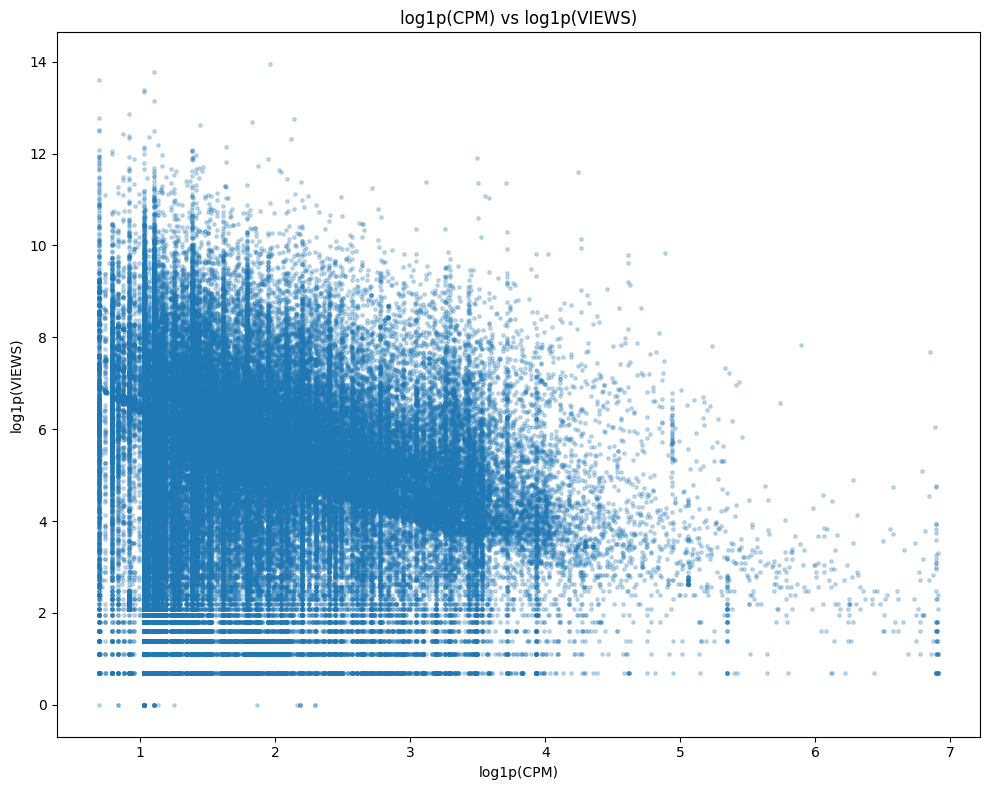

In [134]:
log_cpm = np.log1p(df["CPM"]) # log1p(CPM.values)
log_views = np.log1p(df["VIEWS"]) # log1p(VIEWS.values)

plt.figure(figsize=(10,8))
plt.scatter(log_cpm, log_views, s=6, alpha=0.25) # scatter to see correlation between CPM and VIEWS
plt.title("log1p(CPM) vs log1p(VIEWS)")
plt.xlabel("log1p(CPM)")
plt.ylabel("log1p(VIEWS)")
plt.tight_layout()
plt.show()

In [133]:
corr = np.corrcoef(log_cpm, log_views)[0,1]
corr

-0.1708494933727653

### 6. Time dynamics: volume and seasonality

In [136]:
daily = (df.groupby("DATE", as_index=False).agg(
            rows=("VIEWS","size"),
            views_sum=("VIEWS","sum"),
            views_median=("VIEWS","median"),
            cpm_median=("CPM","median"))
        )
daily.head()

,DATE,rows,views_sum,views_median,cpm_median
0,2024-10-02,20,2396,53.0,1.2
1,2024-10-03,40,4222,93.0,1.0
2,2024-10-04,21,27365,1014.0,3.0
3,2024-10-06,2,2,1.0,100.0
4,2024-10-07,824,1872867,718.0,1.6


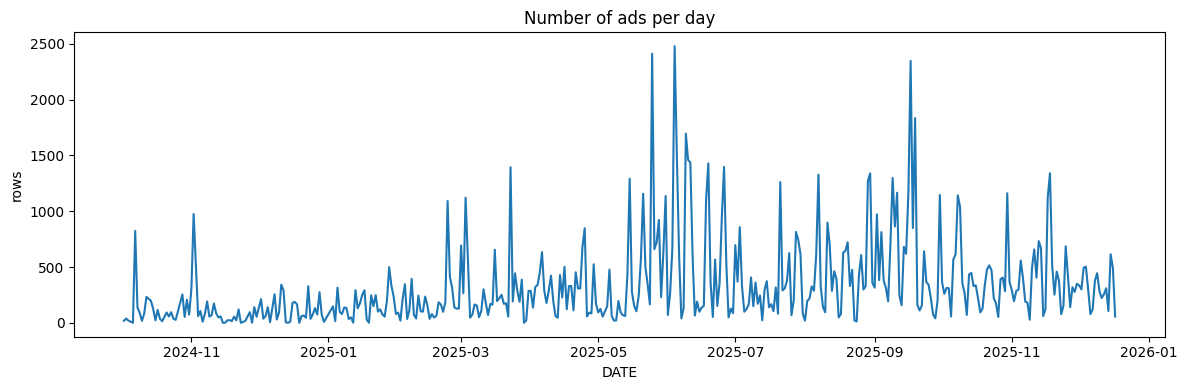

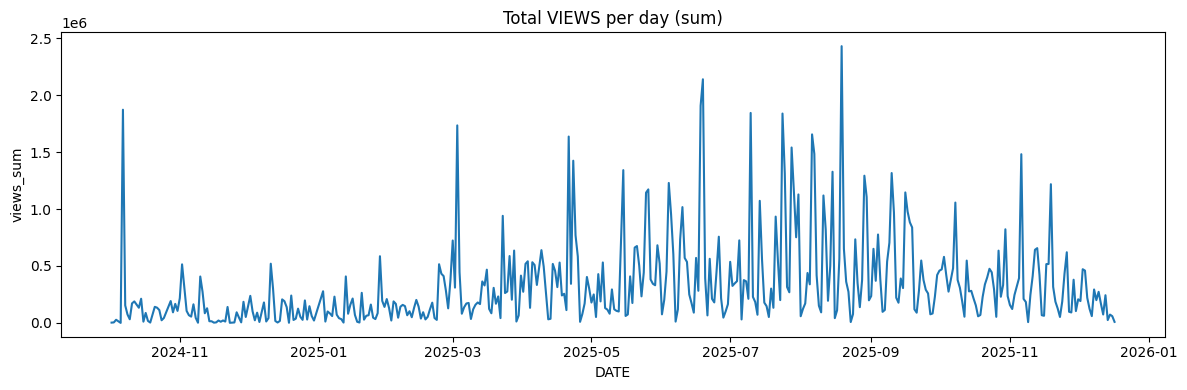

In [119]:
plt.figure(figsize=(12,4))
plt.plot(daily["DATE"], daily["rows"])
plt.title("Number of ads per day")
plt.xlabel("DATE")
plt.ylabel("rows")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(daily["DATE"], daily["views_sum"])
plt.title("Total VIEWS per day (sum)")
plt.xlabel("DATE")
plt.ylabel("views_sum")
plt.tight_layout()
plt.show()

In [120]:
df["DOW"] = df["DATE"].dt.dayofweek  # 0=Mon
dow_stats = df.groupby("DOW", as_index=False).agg(
    rows=("VIEWS","size"),
    views_median=("VIEWS","median"),
    views_mean=("VIEWS","mean"),
    cpm_median=("CPM","median")
)

dow_stats

,DOW,rows,views_median,views_mean,cpm_median
0,0,22733,324.0,1130.808340,3.53
1,1,26387,213.0,880.423428,3.30
2,2,26224,207.5,1008.134190,3.90
3,3,24506,270.0,1164.442667,4.01
4,4,18209,259.0,987.349717,3.59
5,5,11907,314.0,910.420593,3.00
6,6,12643,238.0,779.531361,3.00


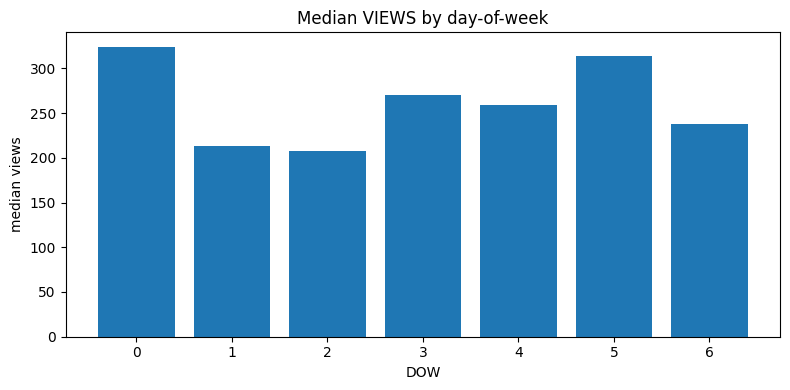

In [137]:
plt.figure(figsize=(8,4))
plt.bar(dow_stats["DOW"], dow_stats["views_median"])
plt.title("Median VIEWS by day-of-week")
plt.xlabel("Day Of a Week")
plt.ylabel("median views")
plt.tight_layout()
plt.show()

### 7. `CHANNEL_NAME` analysis (cardinality, frequency, leakage risk)
We quantify:
- number of unique channels
- how many samples per channel
- how heavy the long tail is (many channels with few samples)

In [123]:
n_channels = df["CHANNEL_NAME"].nunique()
channel_counts = df["CHANNEL_NAME"].value_counts()

n_channels, channel_counts.head(10), channel_counts.describe(percentiles=[0.5,0.9,0.95,0.99])

(35957,
 CHANNEL_NAME
 likeatg              137
 banzaiauto125        127
 uiartemzvezdin       116
 dolgov_auto          115
 kutsenko_invest      112
 moex_arbitrage       110
 auto_zakazz25        105
 asia_express_auto    101
 tradervifree          98
 demwinner             94
 Name: count, dtype: int64,
 count    35957.000000
 mean         3.966098
 std          6.782957
 min          1.000000
 50%          2.000000
 90%          9.000000
 95%         15.000000
 99%         36.000000
 max        137.000000
 Name: count, dtype: float64)

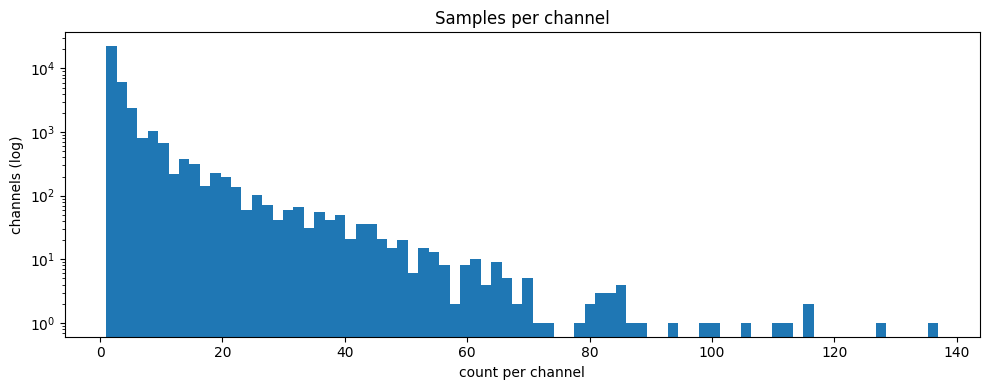

In [138]:
# Distribution of samples per channel (log-y to reveal long tail)
plt.figure(figsize=(10,4))
plt.hist(channel_counts.values, bins=80)
plt.yscale("log")
plt.title("Samples per channel")
plt.xlabel("count per channel")
plt.ylabel("channels (log)")
plt.tight_layout()
plt.show()

### 8. Collisions on (`CPM`, `CHANNEL_NAME`, `DATE`)
If the same key appears multiple times with different VIEWS, the task contains irreducible noise.
We measure how often this happens and what the variability looks like.

In [143]:
key = ["CPM", "CHANNEL_NAME", "DATE"]

# frequency of when the same key occur more than 1 time
counts = df.groupby(key)["VIEWS"].size()
collision_rate = (counts > 1).mean()

# variability of VIEWS within duplicate keys
ranges = (df.groupby(key)["VIEWS"].agg(lambda s: s.max() - s.min()))
ranges = ranges[ranges > 0]

print(f"Collision rate (same inputs repeated): {collision_rate:.3%}")
if len(ranges):
    display(ranges.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
else:
    print("No collisions with different VIEWS detected.")

Collision rate (same inputs repeated): 8.120%


count      9517.000000
mean        585.856572
std        6839.112838
min           1.000000
50%          22.000000
90%         927.000000
95%        2001.200000
99%        9016.120000
max      612276.000000
Name: VIEWS, dtype: float64

### 9. Baseline metrics (time split)
Before any model, we benchmark simple baselines on a **holdout window** (last N days).
This answers: "Is a model better than constant guess?" and sets a sanity floor.

In [144]:
from datetime import timedelta

def train_valid_split_by_time(data: pd.DataFrame, holdout_days: int = 30):
    dmax = data["DATE"].max()
    cutoff = dmax - timedelta(days=holdout_days)
    train = data[data["DATE"] <= cutoff].copy()
    valid = data[data["DATE"] > cutoff].copy()
    return train, valid, cutoff, dmax

train_df, valid_df, cutoff, dmax = train_valid_split_by_time(df, holdout_days=30)
train_df.shape, valid_df.shape, cutoff.date(), dmax.date()

((131923, 9),
 (10686, 9),
 datetime.date(2025, 11, 17),
 datetime.date(2025, 12, 17))

In [145]:
# Metrics
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def rmsle(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.clip(y_true, 0, None)
    y_pred = np.clip(y_pred, 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom))

y_valid = valid_df["VIEWS"].values

# Baseline 1: global median
pred1 = np.full_like(y_valid, fill_value=np.median(train_df["VIEWS"].values), dtype=float)

# Baseline 2: median by day-of-week (computed on train only)
train_df["DOW"] = train_df["DATE"].dt.dayofweek
valid_df["DOW"] = valid_df["DATE"].dt.dayofweek
dow_median = train_df.groupby("DOW")["VIEWS"].median().to_dict()
pred2 = valid_df["DOW"].map(dow_median).fillna(np.median(train_df["VIEWS"].values)).astype(float).values

# Baseline 3: median by (channel) with shrinkage (very naive)
# NOTE: due to long tail, this often overfits/noises. Keep for comparison.
ch_median = train_df.groupby("CHANNEL_NAME")["VIEWS"].median()
ch_count  = train_df["CHANNEL_NAME"].value_counts()
global_med = np.median(train_df["VIEWS"].values)
alpha = 5  # shrinkage strength

# smoothed median approximation: weighted average of channel median and global median
pred3 = []
for ch in valid_df["CHANNEL_NAME"].values:
    if ch in ch_median.index:
        m = float(ch_median.loc[ch])
        n = int(ch_count.loc[ch])
        w = n / (n + alpha)
        pred3.append(w*m + (1-w)*global_med)
    else:
        pred3.append(global_med)
pred3 = np.array(pred3, dtype=float)

baselines = {
    "global_median": pred1,
    "dow_median": pred2,
    "channel_median_shrink": pred3,
}

rows = []
for name, pred in baselines.items():
    rows.append({
        "baseline": name,
        "MAE": mae(y_valid, pred),
        "RMSE": rmse(y_valid, pred),
        "RMSLE": rmsle(y_valid, pred),
        "SMAPE": smape(y_valid, pred),
    })

pd.DataFrame(rows).sort_values("MAE")

,baseline,MAE,RMSE,RMSLE,SMAPE
0,global_median,662.004398,5547.165818,2.124321,1.103390
1,dow_median,664.060453,5548.652700,2.134005,1.104632
2,channel_median_shrink,671.651889,5510.127151,2.044897,1.052407
